# Project 2: Reinforcement Learning

### Group number
### Alice Zhang
### Student Name 2
### ...

Please read all instructions carefully before attempting each part of the problem. Each team only needs to have one submission with all the names of team-members and group number at the beginning of the jupyter notebook.

The jupyter notebook should contain your code, discussions, derivations, analysis and relevant figures. Make sure the code and plots shown in your file can be reproduce when I rerun the code in grading. Feel free to add or move Cells.

In Project 1, you were asked to implement two exact algorithms to solve the Frozen Lake. In this project, you will be asked to implement four different model-free algorithms to solve a similar problem with larger state space, and compare your results.

## 1. The Flags Domain

In the Flags domain, time is broken up into discrete decision periods, and the world is a
square area that is broken up into a 5-by-5 grid of cells, as illustrated in Figure 1 below.
At the beginning of each period, a robot occupies one of the available cells. It is then
allowed to choose a direction of movement (up, down, left or right), and moves to the
corresponding adjacent cell in that direction. However, if the chosen action would take
the robot outside the boundaries of the grid, the robot does not move but remains in
the current cell.

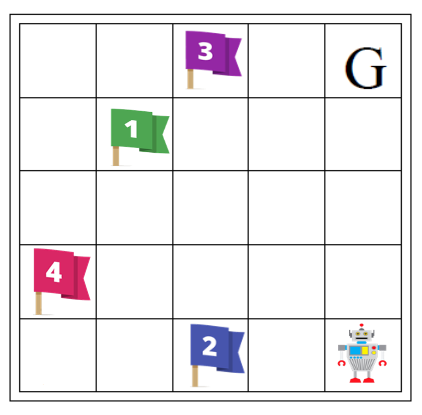



<h1><center>Figure 1: 5x5 Flags Domain</center></h1>

In each episode, the robot begins in the right lower corner. As illustrated in Figure 1, instead of a single
destination G, there are four different flags, numbered 1, 2, 3 and 4, that must be
collected in the correct order (first 1, then 2, etc... to 4). Once the robot has collected all the flags in the correct order and lands on cell G, the task is complete. If the robot collects the wrong flag at the wrong time (e.g. tries to collect 2 first, then 1...), the robot does not have to start over. Instead, the robot is penalized for taking this action, and the wrong flag is not collected (you may assume for training purposes, that the flags that have already been collected so far are kept). The main objective is to collect all the flags in the correct order in the least possible amount of time.

### 2. Problem modelling [15 Marks]

You are tasked with modelling the Flags environment. Then, you are asked to provide a programming description of the problem that will be used to solve it computationally using model-free reinforcement learning.

2.1.Answer the following questions:

(a) Define the state $(S)$ and action spaces $(A)$.[2 Marks]

(b) Construct a reward function ($R$) that aligns with the goal(s) you want your robot to achieve. [2 Marks]

(c) Based on Figure 1, what is an optimal policy for this problem? You may explain your policy by drawing Figure 1 and trace the path the robot should take. Is there more than one optimal policy?[3 Marks]

2.2 Implement the dynamics of the Flags environment. [8 Marks]

In [ ]:
import random
from collections import defaultdict

In [ ]:
class Flags:
  """
    Flag domain problem: GridWorld + Flag Collection (subgoal)

    Actions: up=0, right=1, down=2, left=3
    Note: For states at the corner or edge of the grid world, they will have LESS valid actions.
          Filter out unavailable actions, then select avaialble actions ONLY from remaining ones.
  """

  # actions index
  up, right, down, left = 0, 1, 2, 3

  def __init__(
                self,
                weight : int = 5,
                height : int = 5,
                start_state : tuple = (4,4),
                goal_state : tuple = (0,4),
                flags = [(1,1),(4,2),(0,2),(3,0)],
                step_cost : float = -1.0,
                flag_reward : float = 10.0,
                wrong_flag_penalty : float = -20.0,
                goal_reward : float = 50.0,
                strict_order = True,
                max_step : int = 200
                ):
      self.w = weight
      self.h = height
      self.start = start_state
      self.goal = goal_state

      self.flags = flags
      self.n_flags = len(self.flags)

      self.step_cost = step_cost
      self.flag_reward = flag_reward
      self.wrong_flag_penalty = wrong_flag_penalty
      self.goal_reward = goal_reward

      self.strict_order = strict_order
      self.max_step = max_step


# =================== Helper Functions ====================


  def is_terminal(self, state):
    """
    A state is terminal if it is in the goal state， and collects all 4 flags with correct order.
    """
    r, c, progress = state
    return (r, c) == self.goal and progress == self.n_flags


# =================== Env Configuration ====================

  # return the initial state ...
  def reset(self):
      self.r, self.c = self.start
      self.progress = 0
      self.t = 0
      return (self.r, self.c, self.progress)

  # return a list containing all the possible states in the environment
  def states_space(self):
      return [(r, c, p) for r in range(self.h) for c in range(self.w) for p in range(self.n_flags + 1)]

  # return a list containing all the possible actions corresponding to the given state
  def actions_space(self, state):
      """
      Input: state: 3 elements (r, c, progress) for row, column, and progress (i.e. number of flags collected)
      """
      r, c, _ = state
      actions = []

      if r > 0:
        actions.append(self.up)
      if r < self.h - 1:
        actions.append(self.down)
      if c > 0:
        actions.append(self.left)
      if c < self.w - 1:
        actions.append(self.right)

      return actions

# =================== Env Dynamics ====================


  # environment transition returns s' and r.
  def transition(self, state, action):
    """
    Input:
    state: (r, c, progress) for row, column, and progress (i.e. number of flags)
    action: up=0, right=1, down=2, left=3

    Output

    """

    r, c, progress = state


    # make a move
    self.t += 1
    info = {}   # log tracker purpose only


    # valid action validaition
    valid_actions = self.actions_space((r, c, progress))

    if action not in valid_actions:
      action = None  # Stay if action isn't valid
      r, c = r, c
    # next state
    else:
      if action == 0:
        r -= 1
      elif action == 1:
        c += 1
      elif action == 2:
        r += 1
      elif action == 3:
        c -= 1


    # update state
    self.r, self.c = r, c

    # initialize reward and apply step cost that just happened
    reward = self.step_cost

    # check if the new state has a flag
    stepped_flag_idx = None
    for i, fpos in enumerate(self.flags):
      if (r, c) == fpos:
        stepped_flag_idx = i
        break

    # check if the collected flag is in right order & update reward and progress
    if stepped_flag_idx is not None:
      next_flag_needed = progress
      if next_flag_needed == stepped_flag_idx:
        progress += 1
        reward += self.flag_reward
        info["flag_collected"] = stepped_flag_idx + 1
      else:
        reward += self.wrong_flag_penalty
        info["wrong_flags"] = stepped_flag_idx + 1


    # check if the episode is terminated
    done = False
    # Case 1 - usual episode ends
    if self.is_terminal((r, c, progress)):
      reward += self.goal_reward
      done = True
      info["success"] = True

    # Case 2 - time out by exceeding max steps allowed, then truncate and end
    elif self.t >= self.max_step:
      done = True
      info["time_out"] = True

    self.progress = progress
    state = (self.r, self.c, self.progress)

    return state, reward, done, info



### 3 Monte Carlo Method [35 Marks]

In this section, you are asked to implement Monte Carlo methods to solve the flags domain. Use a discount factor of
$\gamma= 0.99$ for all your experiments.Set the maximum length of each episode to 200 if the terminal state is not reached by this point, the episode ends.Training should proceed for a total of 2000 episodes.


3.1.Create a function $generate\_episode$ which takes as input a policy $\pi$ and the environment. This function should return the tuple of states, actions and rewards generated in an episode following $\pi$.    [5 Marks]

3.2.Implement the first-visit Monte Carlo (for $\epsilon$-soft policies) control algorithm to find the approximate optimal
policy $\pi^*$. Test  $\epsilon=\{0.01, 0.1, 0.25\}$ and include plots in your report for each of these values. What is the best value of $\epsilon$? Why? For each $\epsilon$, did your algorithm converge at all? What was the final policy and
Q-values that you typically obtain (typically, as in the majority of the trials)? Does this correspond to an optimal policy? Visualize the learning process (for instance, change in Q for some state; or any other visualization) to support your claims.  [15 Marks]

3.3.Consider a random behavior policy $b(a|s)=1/|A|$ for every state and action. Use episodes generated with $b$ to find the approximate optimal policy $\pi^*$. First use ordinary importance sampling Monte Carlo control. Then use weighted importance sampling Monte Carlo control. Answer the same questions as in 3.2.  [15 Marks]

### 4 Temporal Diference Control Methods [25 Marks]

In this section, you are asked to implement SARSA and Q-learning methods to solve the flags domain. Use a discount factor of $\gamma= 0.99$ and a learning rate of $\alpha = 0.3$ for all your experiments.Set the maximum length of each episode to 200 if the terminal state is not reached by this point.Training should proceed for a total of 500 episodes.

4.1. Implement the off-policy Q-learning algorithm as discussed in class. Test  $\epsilon=\{0.01, 0.1, 0.25\}$ and  answer the same questions as in 3.2. [13 Marks]

4.2. Implement on-policy one-step Sarsa algorithm as discussed in class. Test  $\epsilon=\{0.01, 0.1, 0.25\}$ and  answer the same questions as in 3.2.[12 Marks]

### 5 Comparing Algorithms [25 Marks]

In the final section of your report, you must compare the different control algorithm you implemented on the Flags domain. In particular, please comment on at least the following issues in your report:

(a) Were the Q-value functions and policies you obtained using each algorithm similar? Were they different? Comment on this using the properties of each algorithm you learned in class [6 Marks]

(b) Use the plots you created for each ε to make a detailed comparison of the performance of the algorithms implemented in 3.2, 4.1 and 4.2. Answer the following questions for each ε you tested. Which one converged the fastest on average? Which one the slowest? Which one
had lower variance and which had higher variance? Why? [6 Marks]

(c) choose one particular ε for all three algorithms and one of the importance sampling Monte Carlo control, compare their testing performances of policies learned by all the algorithm (try to visualize this comparison). [13 Marks]